# Phase 3 — Statistical Validation & EDA
### Transaction Fraud Risk Engine

**Goal:** Visually and statistically confirm which raw and engineered features actually separate fraud from legitimate transactions, before using them in modeling (Phase 5).

**Dataset:** `data/processed/engineered_features.csv` — output of Phase 2's SQL feature engineering (590,540 rows, 14 columns).

## 3.1 Setup

This cell loads the Phase 2 engineered feature table and required libraries.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/processed/engineered_features.csv")
df.shape

(590540, 14)

### Observation:

Data loads correctly — 590,540 rows × 14 columns, matching Phase 2's verified output.

## 3.2 Fraud Rate by ProductCD

`ProductCD` is a categorical field representing the type of product or transaction category associated with each payment. This section calculates the fraud rate — the proportion of transactions flagged as `isFraud = 1` — within each `ProductCD` category, and visualizes the comparison as a bar chart. A bar chart is the appropriate choice here because we are comparing a single proportion (fraud rate) across a small number of discrete, unordered categories, rather than examining a distribution or a relationship between two continuous variables.

The purpose of this check is to determine whether `ProductCD` carries independent predictive signal for fraud, or whether fraud is distributed roughly evenly across product types (in which case this feature would add little value to the model).

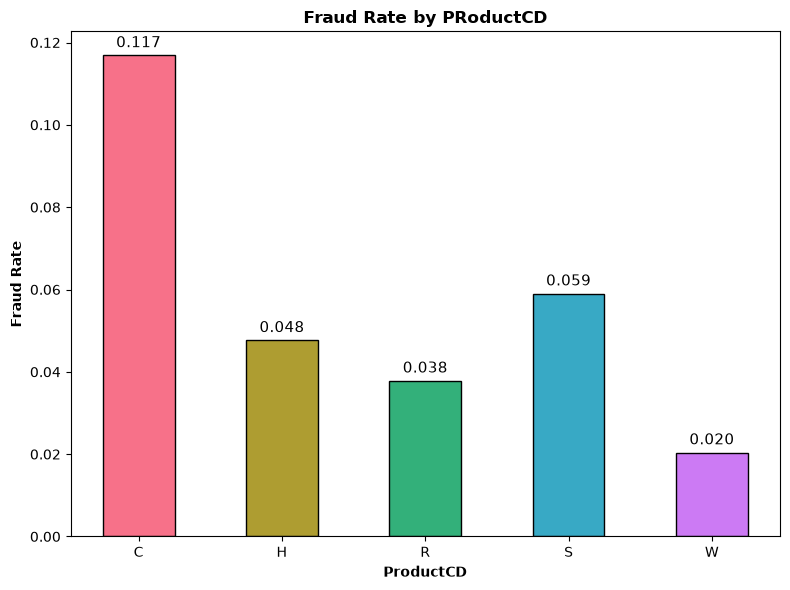

In [2]:
fraud_rate_by_product = df.groupby("ProductCD")["isFraud"].mean() # returns a series

plt.figure(figsize=(8,6))
colors = sns.color_palette("husl", len(fraud_rate_by_product))
plt.bar(fraud_rate_by_product.index, fraud_rate_by_product.values, color=colors, width=0.5, edgecolor="black")
for i, value in enumerate(fraud_rate_by_product.values):
    plt.text(i, value+0.002, f"{value:.3f}", ha="center", fontsize=11)
    
plt.xlabel("ProductCD", fontweight="bold")
plt.ylabel("Fraud Rate", fontweight="bold")
plt.title("Fraud Rate by PRoductCD", fontweight="bold")
plt.tight_layout()
plt.show()

### Observations:

| ProductCD | Fraud Rate |
|---|---|
| C | ~11.7% |
| S | ~5.9% |
| H | ~4.8% |
| R | ~3.8% |
| W | ~2.0% |

- Fraud rate varies nearly **6x** between the highest (`C`, ~11.7%) and lowest (`W`, ~2.0%) categories — a clear, meaningful spread, not noise-level variation.
- `C` stands out as the highest-risk category — about 1 in 9 transactions here is fraud, well above the ~3.5% dataset average.
- `W` sits below the overall average and is likely the highest-volume category in this dataset, which is worth checking next — a low fraud *rate* on a large *volume* can still mean a large number of actual fraud cases.
- **Conclusion:** `ProductCD` is clearly not neutral with respect to fraud — it's a strong candidate feature, and the visual spread here is large enough that it should hold up under a formal chi-square test later in this phase.

## 3.3 Fraud Rate by Card Network and Card Type

`card4` represents the card network (e.g., Visa, Mastercard, Discover, American Express), and `card6` represents the card type (credit or debit). This section calculates the fraud rate within each category of both columns, to check whether either carries independent signal for fraud risk.

**Goal:** determine whether card network or card type meaningfully separates fraud from legitimate transactions, similar to what we found with `ProductCD` in 3.2.

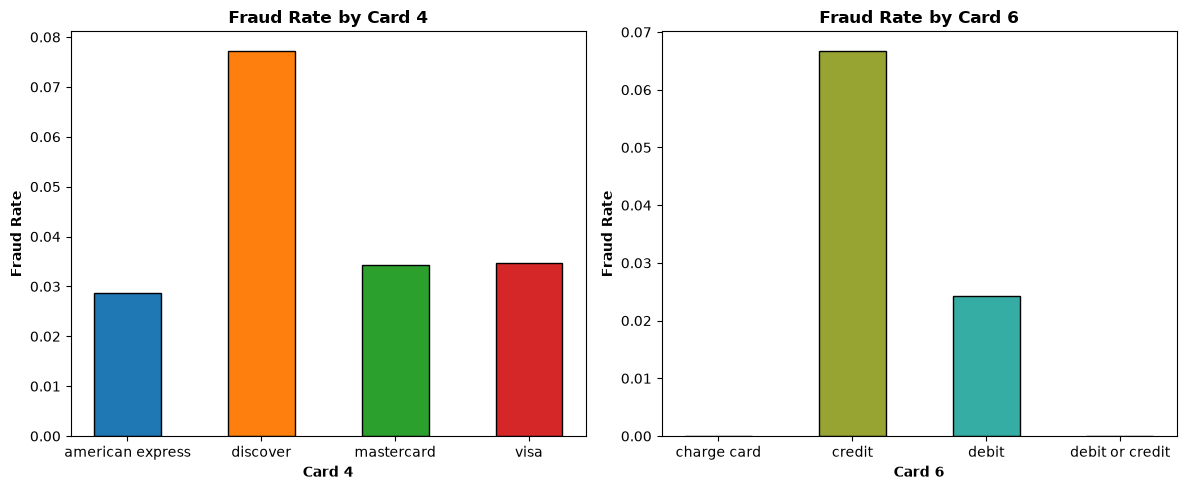

In [3]:
fraud_rate_by_card_4 = df.groupby("card4")["isFraud"].mean() # returns a series
fraud_rate_by_card_6 = df.groupby("card6")["isFraud"].mean() 

colors_1 = sns.color_palette("tab10", len(fraud_rate_by_card_4))
colors_2 = sns.color_palette("husl", len(fraud_rate_by_card_6))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
ax1.bar(fraud_rate_by_card_4.index, fraud_rate_by_card_4.values, color=colors_1, width=0.5, edgecolor="black")
ax2.bar(fraud_rate_by_card_6.index, fraud_rate_by_card_6.values, color=colors_2, width=0.5, edgecolor="black")
ax1.set_xlabel("Card 4", fontweight="bold")
ax1.set_ylabel("Fraud Rate", fontweight="bold")
ax1.set_title("Fraud Rate by Card 4", fontweight="bold")

ax2.set_xlabel("Card 6", fontweight="bold")
ax2.set_ylabel("Fraud Rate", fontweight="bold")
ax2.set_title("Fraud Rate by Card 6", fontweight="bold")
plt.tight_layout()
plt.show()


### Observations:

**Card4 (network):**

| Card4 | Fraud Rate |
|---|---|
| Discover | ~7.7% |
| Mastercard | ~3.4% |
| Visa | ~3.4% |
| American Express | ~2.9% |

**Card6 (type):**

| Card6 | Fraud Rate |
|---|---|
| Credit | ~6.7% |
| Debit | ~2.5% |
| Charge card | ~0% |
| Debit or credit | ~0% |

- **Discover stands out clearly** — its fraud rate (~7.7%) is more than double Mastercard and Visa (~3.4% each), and well above American Express (~2.9%). Mastercard, Visa, and Amex are all fairly close to each other.
- **Credit cards are meaningfully riskier than debit cards** — ~6.7% vs. ~2.5%, roughly a 2.7x difference. This is an intuitive, real-world-consistent pattern: credit transactions are typically card-not-present more often and have historically been a more common fraud target than debit.
- **"Charge card" and "debit or credit" show 0% fraud rate** — this is very likely a **sample size issue**, not a genuine finding. These two categories are probably very rare in the dataset, so a 0% rate could simply mean there were few (or zero) transactions in that group, not that they're truly fraud-proof. This needs a volume check before drawing any conclusion from it.
- **Conclusion:** both `card4` and `card6` show real, usable signal — `card6`'s credit-vs-debit split especially lines up with known real-world fraud patterns, which adds credibility to the dataset and to keeping this as a feature. The 0% categories are a flag to verify with counts, not a genuine "safe" signal.

## 3.4 Transaction Volume by ProductCD, Card4, and Card6

Sections 3.2 and 3.3 showed meaningful fraud rate differences across categories, but also raised an open question: are the extreme values (e.g., `ProductCD = W`'s low rate, `card6`'s two 0% categories) genuine patterns, or artifacts of very small sample sizes? This section checks actual transaction counts per category to answer that.

**Goal:** determine which categories represent large, reliable sample sizes versus small, potentially unstable ones — this tells us how much to trust the fraud rate findings from 3.2 and 3.3.

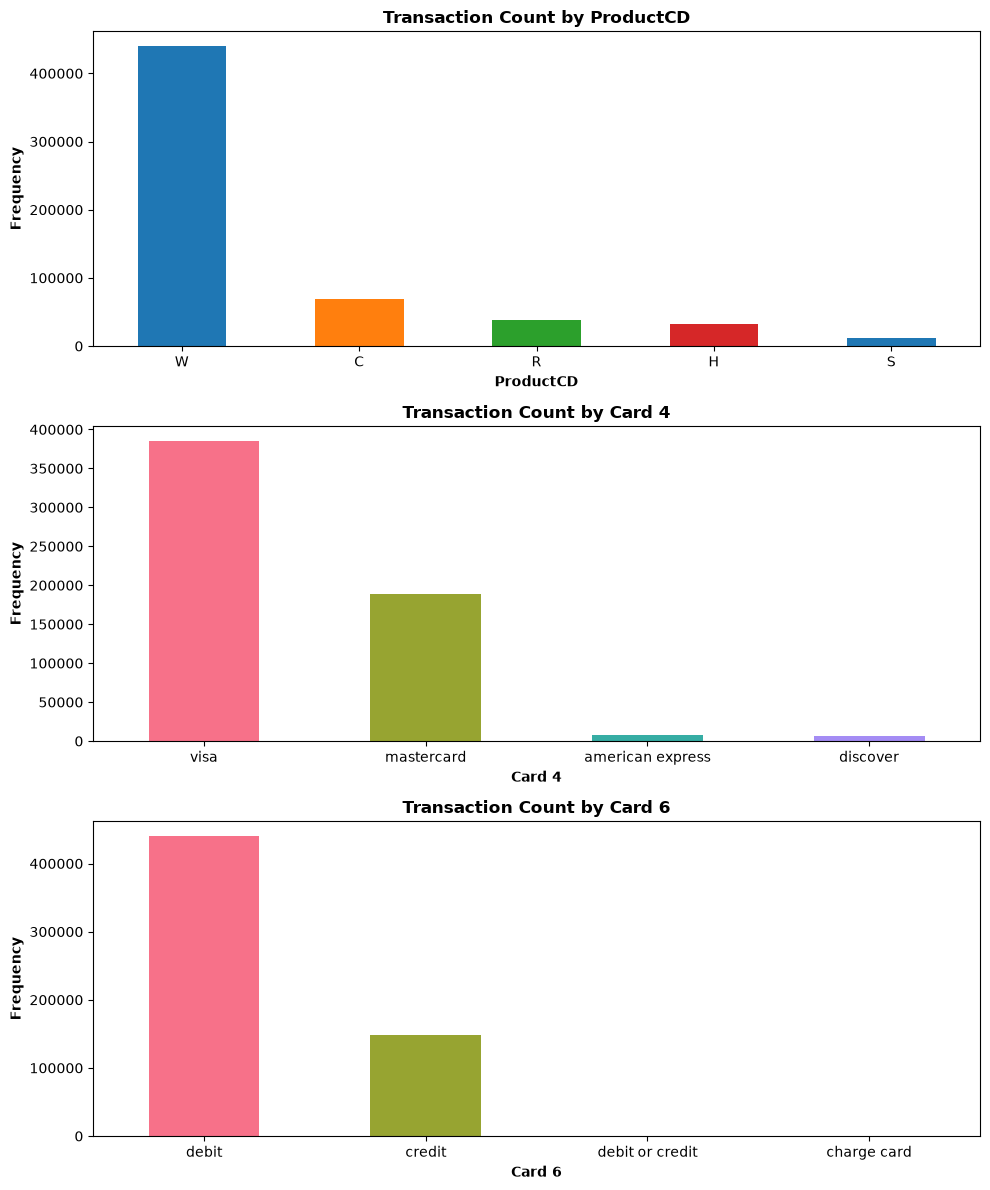

In [4]:
product_cd_transactions = df["ProductCD"].value_counts()
card4_transactions = df["card4"].value_counts()
card6_transactions = df["card6"].value_counts()

fig, axes = plt.subplots(3, 1, figsize=(10,12))
product_cd_transactions.plot(kind="bar", ax=axes[0], color=colors_1)
card4_transactions.plot(kind="bar", ax=axes[1], color=colors_2)
card6_transactions.plot(kind="bar", ax=axes[2], color=colors_2)

axes[0].set_xlabel("ProductCD", fontweight="bold")
axes[0].set_ylabel("Frequency", fontweight="bold")
axes[0].set_title("Transaction Count by ProductCD", fontweight="bold")
axes[0].tick_params(axis="x", rotation=0)

axes[1].set_xlabel("Card 4", fontweight="bold")
axes[1].set_ylabel("Frequency", fontweight="bold")
axes[1].set_title("Transaction Count by Card 4", fontweight="bold")
axes[1].tick_params(axis="x", rotation=0)

axes[2].set_xlabel("Card 6", fontweight="bold")
axes[2].set_ylabel("Frequency", fontweight="bold")
axes[2].set_title("Transaction Count by Card 6", fontweight="bold")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Observations

**ProductCD**

| ProductCD | Count | % of Total |
|---|---|---|
| W | ~440,000 | ~75% |
| C | ~68,000 | ~12% |
| R | ~38,000 | ~6% |
| H | ~33,000 | ~6% |
| S | ~11,000 | ~2% |

**Card 4**

| Card4 | Count |
|---|---|
| Visa | ~385,000 |
| Mastercard | ~188,000 |
| American Express | ~8,000 |
| Discover | ~7,000 |

**Card 6**

| Card6 | Count |
|---|---|
| Debit | ~440,000 |
| Credit | ~148,000 |
| Debit or credit | ~0 |
| Charge card | ~0 |

- **This resolves the open question from 3.2:** `ProductCD = W` isn't just "low fraud rate" — it's also **~75% of all transactions**, by far the dominant category. So its ~2% fraud rate, while low, still represents a large *absolute* number of fraud cases simply due to sheer volume. Meanwhile, `C` (highest fraud rate, ~11.7%) is a much smaller slice (~12% of transactions) — a smaller, but more concentrated, risk pocket.
- **This resolves the open question from 3.3:** `card6`'s two 0%-fraud-rate categories (`"debit or credit"`, `"charge card"`) have **essentially zero transactions** in this dataset — confirming those weren't real findings at all, just an artifact of having almost no data in those categories. They should be treated as negligible/noise, not as genuine "safe" categories.
- **Discover's high fraud rate (from 3.3, ~7.7%) is based on a very small sample** (~7,000 transactions, under 2% of the dataset) — so while the direction of the finding (Discover riskier than Visa/Mastercard) may still hold, the exact 7.7% figure is less statistically stable than, say, Visa's rate, which is backed by ~385,000 transactions.
- **Conclusion:** volume matters as much as rate. `ProductCD = W` and `card4 = Visa`/`card6 = debit` are the dominant, high-confidence categories — most of the dataset's total fraud volume likely comes from these, even though their *rates* looked less alarming. Smaller categories (`S`, `Discover`, `American Express`) show more dramatic rates but rest on thinner evidence, and results from them should be treated with appropriate caution until confirmed statistically.

## 3.5 Distribution of TransactionAmt by Fraud Status

`TransactionAmt` is a continuous numeric field representing the dollar value of each transaction. This section compares how transaction amounts are distributed between fraudulent (`isFraud = 1`) and legitimate (`isFraud = 0`) transactions, to check whether fraud tends to cluster around particular amount ranges.

**Goal:** determine whether `TransactionAmt` on its own carries signal for fraud detection — for example, whether fraudulent transactions skew toward unusually high or unusually low amounts compared to legitimate ones.

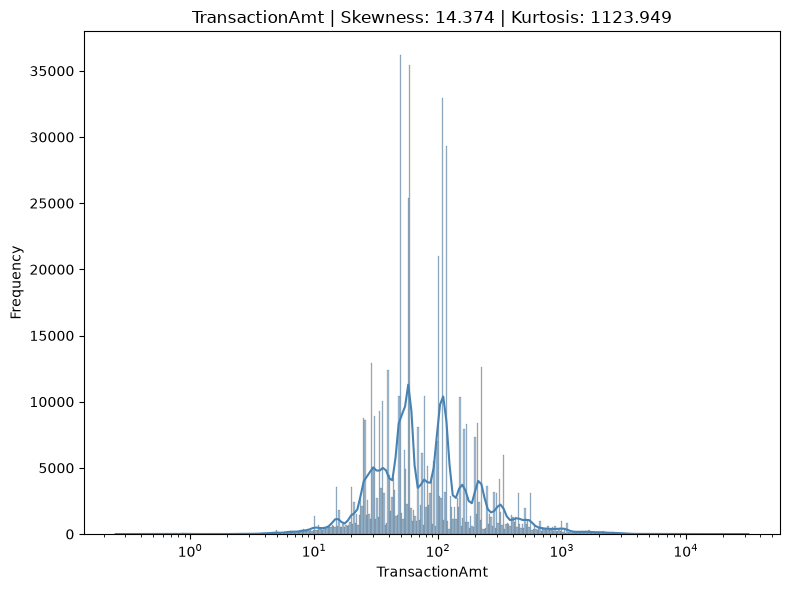

In [5]:
from scipy import stats

plt.figure(figsize=(8,6))
plt.xscale("log")
sns.histplot(df["TransactionAmt"], kde=True, color="steelblue")
skewness = stats.skew(df["TransactionAmt"])
kurtosis = stats.kurtosis(df["TransactionAmt"])
plt.xlabel("TransactionAmt")
plt.ylabel("Frequency")
plt.title(f"TransactionAmt | Skewness: {skewness:.3f} | Kurtosis: {kurtosis:.3f}")
plt.tight_layout()
plt.show()

### Observations:

- On the log scale, `TransactionAmt` shows a clear multi-peak pattern rather than one smooth curve — noticeable clusters around roughly **$30-60**, **$100-120**, and smaller bumps near **$200-300**. This suggests transaction amounts aren't randomly distributed — they likely cluster around common price points (e.g., standard product prices, subscription tiers, or round-number amounts).
- **Skewness: 14.37** — a very high positive skew, confirming what we expected: a small number of very large transactions (up to the tens of thousands) are pulling the distribution's tail far to the right, even though the bulk of transactions sit in a much smaller range.
- **Kurtosis: 1123.9** — an extremely high value, meaning the distribution has a much sharper peak and much heavier/longer tail than a normal distribution would. In plain terms: most transactions are tightly clustered in a narrow amount range, but rare extreme outliers exist far beyond that range.
- **Practical takeaway:** the raw distribution alone doesn't yet tell us whether fraud clusters in a particular amount range — this chart only shows the overall pattern, not fraud vs. non-fraud separately. The natural next step is to split this exact chart by `isFraud`, to see whether fraudulent transactions cluster around different amount peaks than legitimate ones (e.g., often fraud tests small amounts first, or targets specific higher-value ranges).

## 3.6 Distribution of TransactionAmt by Fraud Status

Section 3.5 examined `TransactionAmt`'s overall distribution across all transactions combined. This section splits that same view by `isFraud`, comparing the amount distribution of fraudulent transactions against legitimate ones on the same log-scaled axis, to check whether fraud clusters around different transaction amounts than normal activity.

**Goal:** determine whether `TransactionAmt` carries fraud-specific signal — for example, whether fraudulent transactions skew toward unusually small "testing" amounts, unusually large amounts, or show no meaningful difference from legitimate transactions at all.

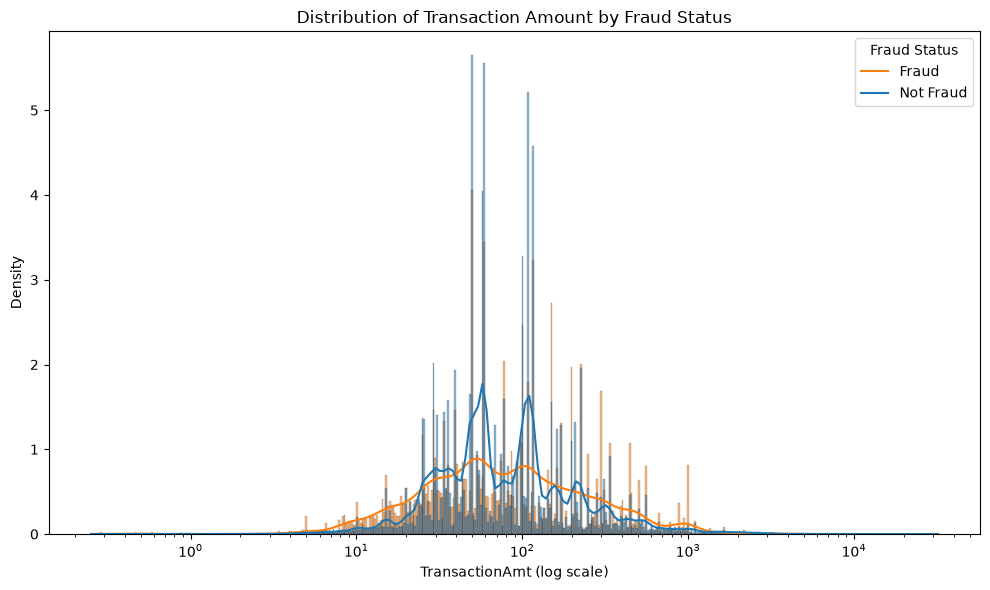

In [6]:
plt.figure(figsize=(10,6))
plt.xscale("log")
sns.histplot(
    data=df, 
    x="TransactionAmt",
    hue="isFraud",
    kde=True,
    alpha=0.5,
    stat="density",
    common_norm=False,
    )

plt.xlabel("TransactionAmt (log scale)")
plt.title("Distribution of Transaction Amount by Fraud Status")
plt.ylabel("Density")
plt.legend(title="Fraud Status", labels=["Fraud", "Not Fraud"])
plt.tight_layout()
plt.show()

**Observations**

- With density normalization applied, both fraud (orange) and non-fraud (blue) distributions are now visible on comparable scales, rather than fraud being flattened by its much smaller raw count.
- **Legitimate transactions (blue)** show sharp, well-defined peaks around specific amounts (~$50-60, ~$100-120) — consistent with common real-world price points or subscription amounts, matching what we saw in the combined view in 3.5.
- **Fraudulent transactions (orange)** show a noticeably smoother, broader distribution — less concentrated at those same sharp peaks, and comparatively more spread across the low-to-mid range (~$10-300). This suggests fraud doesn't cluster around the same "typical" price points that legitimate purchases do — an intuitive result, since fraudulent transactions aren't tied to real product pricing patterns.
- **In the higher amount range (roughly $300-1500)**, the orange (fraud) line sits visibly above the blue (non-fraud) line at several points — suggesting fraud is relatively *more* common, proportionally, at higher transaction amounts than legitimate activity is.
- **Conclusion:** `TransactionAmt` does appear to carry some fraud-relevant signal — not because fraud has one obvious "danger zone," but because its distribution shape genuinely differs from legitimate transactions: smoother/less peaked overall, and relatively more weight in the higher-amount range. This supports keeping `TransactionAmt` as a useful raw feature, and adds credibility to `amt_deviation_ratio` (our Phase 2 engineered feature), since unusual amounts — not just high amounts — appear meaningfully tied to fraud risk.

### 3.7 Distribution of amt_deviation_ratio by Fraud Status

This section examines `amt_deviation_ratio` — the Phase 2 engineered feature measuring how far a transaction's amount deviates from that specific card's historical average — split by fraud status, using the same density-normalized distribution approach as 3.6.

**Goal:** determine whether this engineered feature separates fraud from legitimate transactions more clearly than the raw `TransactionAmt` did in 3.6 — testing whether the added engineering effort from Phase 2 is actually paying off with real signal.

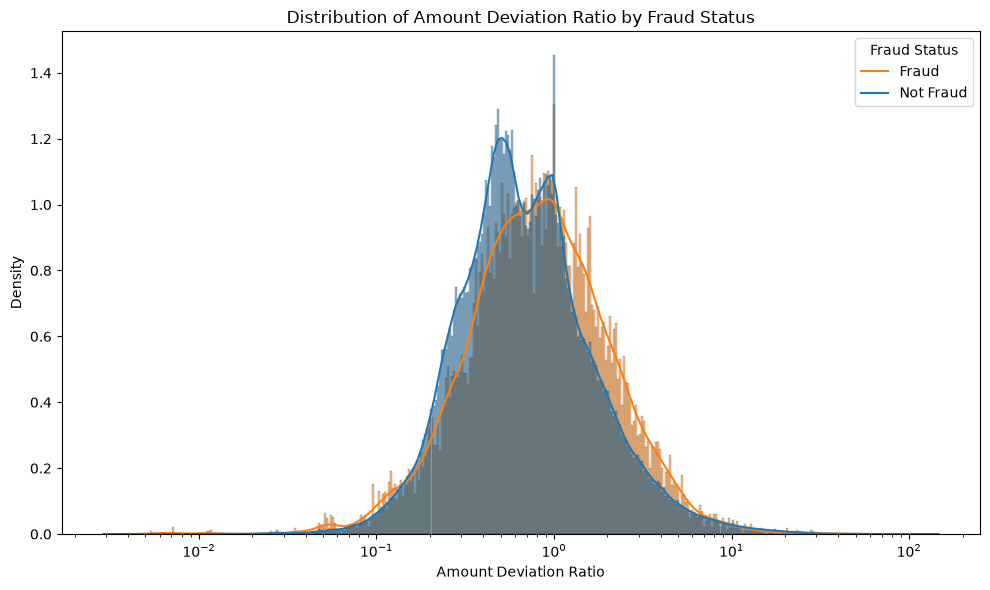

In [7]:
plt.figure(figsize=(10,6))
plt.xscale("log")
sns.histplot(
    data=df, 
    x="amt_deviation_ratio",
    hue="isFraud",
    kde=True,
    alpha=0.5,
    stat="density",
    common_norm=False,
    )

plt.xlabel("Amount Deviation Ratio")
plt.title("Distribution of Amount Deviation Ratio by Fraud Status")
plt.ylabel("Density")
plt.legend(title="Fraud Status", labels=["Fraud", "Not Fraud"])
plt.tight_layout()
plt.show()

**Observations**

- **Non-fraud (blue)** shows a sharp, tight peak right around a ratio of **~0.5-0.7** — meaning most legitimate transactions are close to, or somewhat below, that card's typical spending amount. This makes intuitive sense: normal purchasing behavior tends to stay consistent with a person's usual spending pattern.
- **Fraud (orange)** shows a visibly flatter, more spread-out distribution, with its peak sitting slightly higher (~1.0) and noticeably more weight in the **higher ratio range (2x-10x and beyond)** compared to non-fraud. This matches the exact hypothesis behind why we engineered this feature in Phase 2: fraud tends to deviate more from a card's normal spending pattern than legitimate transactions do.
- **The clearest separation is in the tail (right side, ratio > 2)** — fraud's orange line sits consistently above blue's non-fraud line in this region, meaning a disproportionate share of fraud involves transactions well above a card's historical norm.
- **Comparison to 3.6 (raw TransactionAmt):** this separation is noticeably cleaner and more consistent than what raw dollar amount showed on its own. This is a meaningful result — it suggests the Phase 2 engineering effort actually added real, usable signal beyond what the raw column alone provided, rather than just adding complexity for its own sake.
- **Conclusion:** `amt_deviation_ratio` looks like one of the strongest individual features examined so far in this phase. It's a strong candidate to confirm formally with a KS-test (comparing the fraud and non-fraud distributions statistically) later in this phase.

### 3.8 Distribution of card_txn_count_so_far by Fraud Status

This section examines `card_txn_count_so_far` — the Phase 2 engineered feature counting how many prior transactions a card has made — split by fraud status, using the same density-normalized distribution approach as 3.6 and 3.7.

**Goal:** determine whether newer cards (low transaction history) or established cards (high transaction history) show different fraud rates — testing whether transaction history itself is a useful fraud signal.

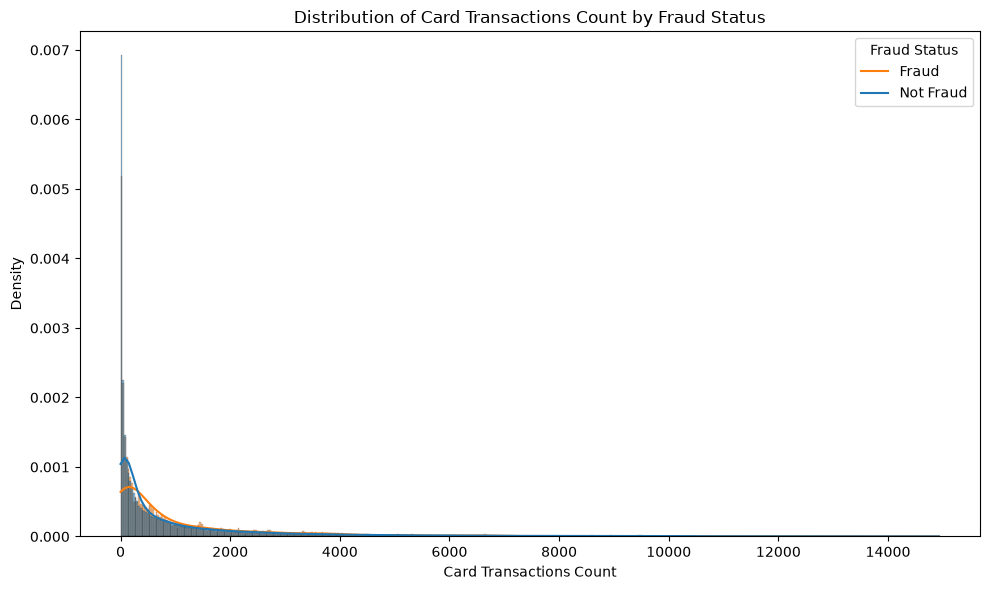

In [8]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df, 
    x="card_txn_count_so_far",
    hue="isFraud",
    kde=True,
    alpha=0.5,
    stat="density",
    common_norm=False,
    )

plt.xlabel("Card Transactions Count")
plt.title("Distribution of Card Transactions Count by Fraud Status")
plt.ylabel("Density")
plt.legend(title="Fraud Status", labels=["Fraud", "Not Fraud"])
plt.tight_layout()
plt.show()

**Observations**

- Both fraud (orange) and non-fraud (blue) distributions are heavily concentrated near **low transaction counts (0-500)** — the vast majority of transactions, fraud or not, come from cards with relatively little prior history. This makes sense since a large share of cards simply haven't accumulated many transactions in this dataset's time window.
- **Non-fraud peaks slightly higher and slightly further left** than fraud in the very low-count region — suggesting legitimate transactions are marginally more concentrated among cards with very little history (brand new or lightly-used cards).
- **Fraud's curve sits marginally above non-fraud's in the mid-range** (roughly 500-2000 prior transactions) — a subtle but visible shift, suggesting fraud is slightly *more* likely, proportionally, to occur on cards with a moderate transaction history compared to legitimate transactions.
- **The separation here is much weaker than what we saw with `amt_deviation_ratio` in 3.7** — the two curves largely overlap, with only a modest divergence rather than a clear, distinct pattern. This suggests `card_txn_count_so_far` on its own is a much weaker fraud signal than the deviation ratio.
- **Conclusion:** `card_txn_count_so_far` shows only mild separation between fraud and non-fraud when viewed alone. It may still add value in combination with other features (e.g., a low `card_txn_count_so_far` paired with a high `amt_deviation_ratio` could be more meaningful together than either alone), but as a standalone feature, it appears weaker than `amt_deviation_ratio`.

### 3.9 Fraud Rate by has_identity_data

This section checks whether `has_identity_data` — the Phase 2 flag indicating whether a transaction has a matching identity record — correlates with fraud. Since this is a binary categorical feature (1/0), fraud rate is calculated for each group and compared, similar to the approach used for `ProductCD` in 3.2.

**Goal:** determine whether the mere presence or absence of identity data is itself a useful fraud signal, validating (or challenging) the reasoning behind engineering this feature in Phase 2.

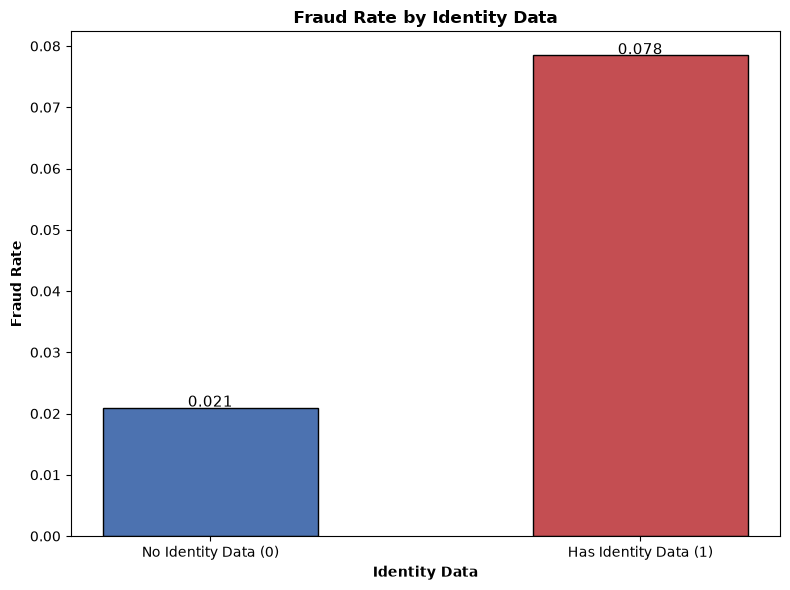

In [9]:
fraud_rate_by_identity = df.groupby("has_identity_data")["isFraud"].mean() 

plt.figure(figsize=(8,6))
colors = ["#4C72B0", "#C44E52"]
plt.bar(fraud_rate_by_identity.index, fraud_rate_by_identity.values, color=colors, width=0.5, edgecolor="black")
for i, value in enumerate(fraud_rate_by_identity.values):
    plt.text(i, value+0.0002, f"{value:.3f}", ha="center", fontsize=11)

plt.xticks([0, 1], ["No Identity Data (0)", "Has Identity Data (1)"])    
plt.xlabel("Identity Data", fontweight="bold")
plt.ylabel("Fraud Rate", fontweight="bold")
plt.title("Fraud Rate by Identity Data", fontweight="bold")
plt.tight_layout()
plt.show()

## Observations

| has_identity_data | Fraud Rate |
|---|---|
| No identity data (0) | ~2.1% |
| Has identity data (1) | ~7.8% |

- This is a genuinely striking finding: transactions **with** identity data show a fraud rate over **3.7x higher** than transactions without it (~7.8% vs. ~2.1%).
- This is somewhat counter-intuitive at first glance — one might expect *more* identity information to mean *more* verification and therefore *lower* fraud risk. The opposite pattern here suggests something different is going on: it's possible that certain transaction types or channels that are more prone to fraud also happen to be the ones more likely to capture identity/device data in the first place (e.g., app or browser-based transactions may both collect identity signals *and* be more exposed to fraud, compared to simpler transaction types that collect neither).
- **Important caveat:** this is a correlation, not a causal explanation — we don't know *why* this pattern exists, only that it's real and substantial. The dataset doesn't give us enough context to say identity data itself "causes" fraud; more likely, both are downstream of some other factor (e.g., transaction/device type) we haven't isolated yet.
- **Conclusion:** this validates the reasoning behind engineering `has_identity_data` in Phase 2 — treating the presence/absence of identity data as a signal, rather than discarding the ~75% of rows without it, was the right call. This is one of the clearer, more dramatic separations found in this entire phase so far, comparable to `ProductCD`'s spread in 3.2.

## 3.10 Chi-Square Tests: card4, card6, and has_identity_data vs. Fraud Status

Extending the chi-square test from 3.9 to the categorical features examined in this phase — `ProductCD`,`card4`, `card6`, and `has_identity_data` — to formally confirm whether the fraud rate differences observed visually in 3.3 and 3.9 are statistically significant.

**Method:** the chi-square test of independence, looping across all three remaining categorical features for efficiency.

In [ ]:
from scipy.stats import chi2_contingency, ks_2samp

categorical_features = ["ProductCD", "card4", "card6", "has_identity_data"]

for col in categorical_features:
  contingency_table = pd.crosstab(df[col], df["isFraud"]) # summary table
  chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

  print(f"Chi-Square Statistic: {chi2_stat:.4f}")
  print(f"p-value: {p_val:.4e}")
  print(f"Degrees of Freedom: {dof}")

  if p_val < 0.05:
    print(
      f"Result: {col} is statistically SIGNIFICANTLY related to fraud status."
    )
  else:
    print(f"Result: {col} has NO significant relationship with fraud status.")
  print("-"*40)  

Chi-Square Statistic: 16742.1715
p-value: 0.0000e+00
Degrees of Freedom: 4
Result: ProductCD is statistically SIGNIFICANTLY related to fraud status.
----------------------------------------
Chi-Square Statistic: 364.8741
p-value: 8.9698e-79
Degrees of Freedom: 3
Result: card4 is statistically SIGNIFICANTLY related to fraud status.
----------------------------------------
Chi-Square Statistic: 5957.0323
p-value: 0.0000e+00
Degrees of Freedom: 3
Result: card6 is statistically SIGNIFICANTLY related to fraud status.
----------------------------------------
Chi-Square Statistic: 10683.6359
p-value: 0.0000e+00
Degrees of Freedom: 1
Result: has_identity_data is statistically SIGNIFICANTLY related to fraud status.
----------------------------------------


### Observations

| Feature | Chi-Square Statistic | p-value | Degrees of Freedom | Significant? |
|---|---|---|---|---|
| ProductCD | 16,742.17 | ~0.0000 | 4 | ✅ Yes |
| card4 | 364.87 | ~8.97e-79 | 3 | ✅ Yes |
| card6 | 5,957.03 | ~0.0000 | 3 | ✅ Yes |
| has_identity_data | 10,683.64 | ~0.0000 | 1 | ✅ Yes |

- All four categorical features show a statistically significant relationship with fraud status — every p-value is far below the 0.05 significance threshold, several effectively at zero.
- **Relative strength, based on chi-square statistic size:** `ProductCD` (16,742) shows the strongest relationship, followed closely by `has_identity_data` (10,684) and `card6` (5,957). `card4` (365) is comparatively the weakest of the four — still highly significant, but a noticeably smaller effect than the other three. This is consistent with what we saw visually: `card4`'s fraud rate differences (2.9%-7.7%) were real but less extreme than, say, `ProductCD`'s (2.0%-11.7%).
- **Conclusion:** all four categorical features are confirmed, not just suspected, to carry genuine fraud signal. Every categorical feature examined in this phase — both raw (`ProductCD`, `card4`, `card6`) and engineered (`has_identity_data`) — earns its place in the feature set going into Phase 5's modeling, backed by statistical evidence rather than visual impression alone.

## 3.11 Kolmogorov-Smirnov Tests: Numeric Features vs. Fraud Status

Extending the distribution comparisons from 3.6, 3.7, and 3.8 (TransactionAmt, amt_deviation_ratio, card_txn_count_so_far) with a formal KS-test, to confirm whether the visual differences between fraud and non-fraud distributions are statistically significant, rather than relying on visual impression alone.

**Method:** for each numeric feature, fraud and non-fraud values are split into two groups, and a two-sample KS-test compares their cumulative distributions.

In [14]:
numerical_features = ["TransactionAmt", "amt_deviation_ratio", "card_txn_count_so_far"]

for col in numerical_features:
    fraud_values = df[df["isFraud"] == 1][col].dropna()
    non_fraud_values = df[df["isFraud"] == 0][col].dropna()
    
    ks_stat, p_val = ks_2samp(fraud_values, non_fraud_values)
    
    print(f"Feature: {col}")
    print(f"KS Statistic (D): {ks_stat:.4f}")
    print(f"p-value: {p_val:.4e}")

    if p_val < 0.05:
      print(
          f"Result: {col} distributions are SIGNIFICANTLY different for fraud"
          " vs non-fraud. Strong predictor!"
      )
    else:
      print(
          f"Result: {col} distributions are too similar. Weak or no predictive"
          " power."
      )
    print(f"-"*40)  

Feature: TransactionAmt
KS Statistic (D): 0.0756
p-value: 1.0923e-99
Result: TransactionAmt distributions are SIGNIFICANTLY different for fraud vs non-fraud. Strong predictor!
----------------------------------------
Feature: amt_deviation_ratio
KS Statistic (D): 0.0986
p-value: 3.2200e-166
Result: amt_deviation_ratio distributions are SIGNIFICANTLY different for fraud vs non-fraud. Strong predictor!
----------------------------------------
Feature: card_txn_count_so_far
KS Statistic (D): 0.0587
p-value: 3.7219e-60
Result: card_txn_count_so_far distributions are SIGNIFICANTLY different for fraud vs non-fraud. Strong predictor!
----------------------------------------


### Observations

| Feature | KS Statistic (D) | p-value | Significant? |
|---|---|---|---|
| TransactionAmt | 0.0756 | ~1.09e-99 | ✅ Yes |
| amt_deviation_ratio | 0.0986 | ~3.22e-166 | ✅ Yes |
| card_txn_count_so_far | 0.0587 | ~3.72e-60 | ✅ Yes |

- All three numeric features show statistically significant distribution differences between fraud and non-fraud transactions — every p-value is far below the 0.05 threshold.
- **`amt_deviation_ratio` has the largest KS statistic (0.0986)** — confirming numerically what 3.7 showed visually: this Phase 2 engineered feature separates fraud from non-fraud more strongly than either raw `TransactionAmt` (0.0756) or `card_txn_count_so_far` (0.0587).
- **`card_txn_count_so_far` has the smallest KS statistic**, consistent with 3.8's finding that this feature showed only mild visual separation — it's statistically real, but comparatively the weakest of the three numeric signals.
- **Conclusion:** all three numeric features are confirmed as genuine, statistically defensible fraud signals. Critically, this validates the core premise behind Phase 2's engineering effort — `amt_deviation_ratio`, a feature we built rather than one that came raw in the dataset, is the single strongest numeric predictor found in this entire phase.

## 3.12 Box Plots: Numeric Features by Fraud Status

This section presents box plots for all three numeric features examined in this phase (`TransactionAmt`, `amt_deviation_ratio`, `card_txn_count_so_far`), comparing fraud vs. non-fraud side by side. Box plots complement the histograms from 3.6–3.8 by showing median, interquartile range (the middle 50% of values), and overall spread in a single, compact view — outliers are hidden (`showfliers=False`) to keep the boxes readable, since this dataset's extreme outliers were already visible in the histograms.

**Goal:** provide a clean, summary-level visual confirmation of the distribution differences already established statistically in 3.10–3.12.

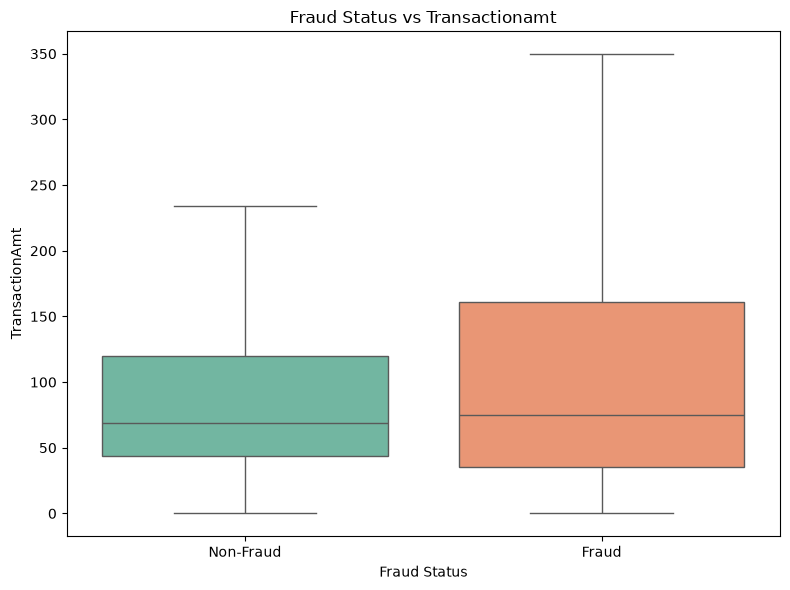

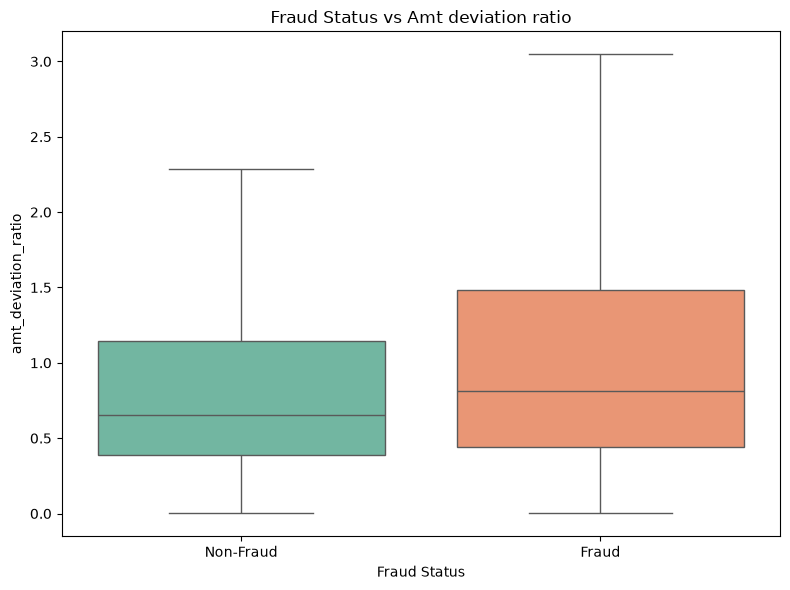

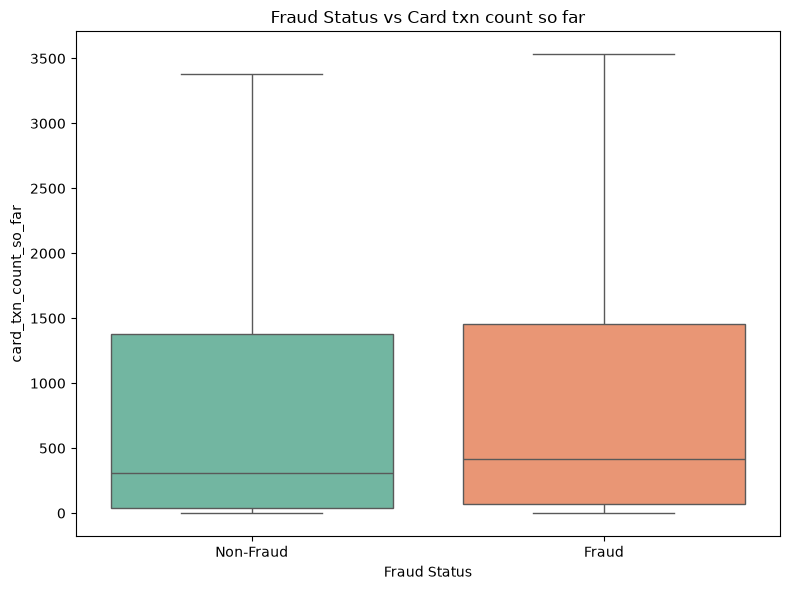

In [ ]:
numerical_features = ["TransactionAmt", "amt_deviation_ratio", "card_txn_count_so_far"]

for col in numerical_features:
    plt.figure(figsize=(8,6))
    sns.boxplot(x="isFraud",
                y=col,
                data=df,
                hue="isFraud",
                palette="Set2",
                legend=False,
                showfliers=False # hides extreme outliers
                )
    
    plt.xticks(ticks=[0, 1], labels=["Non-Fraud", "Fraud"])

    plt.title(f"Fraud Status vs {col.capitalize().replace("_", " ")}")
    plt.xlabel("Fraud Status")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Observations

| Feature | Non-Fraud Median | Fraud Median | Non-Fraud IQR | Fraud IQR |
|---|---|---|---|---|
| TransactionAmt | ~$68 | ~$75 | $43–$120 | $36–$160 |
| amt_deviation_ratio | ~0.65 | ~0.81 | 0.39–1.14 | 0.45–1.48 |
| card_txn_count_so_far | ~300 | ~410 | 40–1,370 | 90–1,450 |

- **`TransactionAmt`:** medians are close ($68 vs. $75), but fraud's box is noticeably wider (up to $160 vs. $120 at the upper quartile), and fraud's upper whisker reaches much higher ($350 vs. $233). This matches 3.6's finding — fraud isn't defined by one typical amount, but shows more spread toward higher values.
- **`amt_deviation_ratio`:** this shows the clearest shift of the three — fraud's entire box sits higher than non-fraud's (median 0.81 vs. 0.65, upper quartile 1.48 vs. 1.14). This visually confirms 3.7's finding and the KS-test result: fraud transactions deviate more from a card's historical spending pattern than legitimate ones do.
- **`card_txn_count_so_far`:** the two boxes overlap heavily, with only a modest shift in median (410 vs. 300) and upper quartile (1,450 vs. 1,370). This matches 3.8's finding — statistically real, but the weakest separation of the three numeric features.
- **Conclusion:** the box plots reinforce the same ranking found throughout this phase — `amt_deviation_ratio` shows the strongest, clearest separation, `TransactionAmt` shows moderate separation concentrated in spread rather than median, and `card_txn_count_so_far` shows the weakest (though still statistically significant) separation.

## 3.13 Phase 3 Summary

**Objective recap:** this phase evaluated whether raw and Phase 2 engineered features carry genuine, statistically defensible signal for fraud detection — using visual EDA followed by formal statistical testing, rather than relying on visual impression alone.

**Features tested — all 7 confirmed statistically significant:**

| Feature | Type | Test | Result |
|---|---|---|---|
| ProductCD | Categorical | Chi-square | ✅ Significant (χ²=16,742) |
| card4 | Categorical | Chi-square | ✅ Significant (χ²=365) |
| card6 | Categorical | Chi-square | ✅ Significant (χ²=5,957) |
| has_identity_data | Categorical (engineered) | Chi-square | ✅ Significant (χ²=10,684) |
| TransactionAmt | Numeric | KS-test | ✅ Significant (D=0.076) |
| amt_deviation_ratio | Numeric (engineered) | KS-test | ✅ Significant (D=0.099) |
| card_txn_count_so_far | Numeric (engineered) | KS-test | ✅ Significant (D=0.059) |

**Key findings:**
- Every feature examined — both raw dataset columns and Phase 2 engineered features — shows a statistically significant relationship with fraud, with p-values far below the 0.05 threshold across the board.
- **`amt_deviation_ratio` was the strongest individual feature found in this entire phase**, outperforming raw `TransactionAmt` on both visual separation and KS statistic. This directly validates the Phase 2 feature engineering effort.
- **`has_identity_data` produced the most striking finding**: transactions with identity data show a fraud rate over 3.7x higher than those without (~7.8% vs. ~2.1%) — a genuinely useful, if counter-intuitive, signal.
- **Volume matters as much as rate** — checking transaction counts per category (3.4) corrected a potentially misleading read of `ProductCD = W`'s low fraud rate and exposed two `card6` categories with statistically meaningless 0% rates due to near-zero sample size.

**Carried forward to Phase 4/5:** all 7 features are retained with statistical justification: `ProductCD`, `card4`, `card6`, `TransactionAmt`, `has_identity_data`, `card_txn_count_so_far`, `amt_deviation_ratio`.

**Phase 3 status:** ✅ Complete.